In [18]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [19]:
zip_path = ("/content/Plant_Disease_Workshop.zip")
extract_path = "/content"
with zipfile.ZipFile(zip_path,"r") as zip_ref:
  zip_ref.extractall(extract_path)
  print("Dataset extracted successfully!")

Dataset extracted successfully!


In [20]:
print(os.listdir("/content"))

['.config', 'Plant_Disease_Workshop', 'Plant_Disease_Workshop.zip', '.ipynb_checkpoints', 'sample_data']


In [21]:
dataset_path = ("/content/Plant_Disease_Workshop")
print(os.listdir(dataset_path))

['val', 'train']


In [22]:
train_path = ("/content/Plant_Disease_Workshop/train")
print(os.listdir(dataset_path))

['val', 'train']


In [23]:
train_path = ("/content/Plant_Disease_Workshop/val")
print(os.listdir(dataset_path))

['val', 'train']


In [24]:
print("========== TRAIN DATA ==========\n")
for folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, folder)
    print(folder, ":", len(os.listdir(folder_path)), "images")

print("\n========== VALIDATION DATA ==========\n")
for folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, folder)
    print(folder, ":", len(os.listdir(folder_path)), "images")

========== TRAIN DATA ==========

Potato___Late_blight : 200 images
Potato___Early_blight : 200 images
Potato___healthy : 31 images

========== VALIDATION DATA ==========

Potato___Late_blight : 200 images
Potato___Early_blight : 200 images
Potato___healthy : 31 images


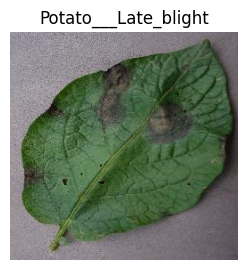

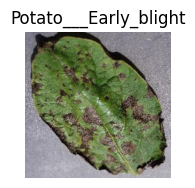

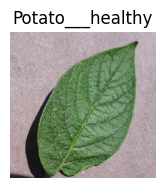

In [25]:
plt.figure(figsize=(10,10))
classes = os.listdir(train_path)
for i, folder in enumerate(classes):
    image_name = os.listdir(os.path.join(train_path, folder))[0]
    image_path = os.path.join(train_path, folder, image_name)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.subplot(1,3,i+1)
    plt.imshow(image)
    plt.title(folder)
    plt.axis("off")
    plt.show()

In [26]:
train_path = "/content/Plant_Disease_Workshop/train"
val_path = "/content/Plant_Disease_Workshop/val"
image_size = (64,64)

In [27]:
X_train = []
y_train = []

X_val=[]
y_val=[]


In [28]:
for label in os.listdir(train_path):
  folder_path = os.path.join(train_path, label)
  for image_name in os.listdir(folder_path):
    image_path = os.path.join(folder_path, image_name)
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    X_train.append(image)
    y_train.append(label)
print("Training Image Loaded Successfully")

Training Image Loaded Successfully


In [29]:
for label in os.listdir(val_path):
  folder_path = os.path.join(val_path, label)
  for image_name in os.listdir(folder_path):
    image_path = os.path.join(folder_path, image_name)
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    X_val.append(image)
    y_val.append(label)
print("Validation Image Loaded Successfully")

Validation Image Loaded Successfully


In [30]:
print("Training images:",len(X_train))
print("Training labels:",len(y_train))
print()
print("Validation images:",len(X_val))
print("Validation labels:",len(y_val))

Training images: 1721
Training labels: 1721

Validation images: 431
Validation labels: 431


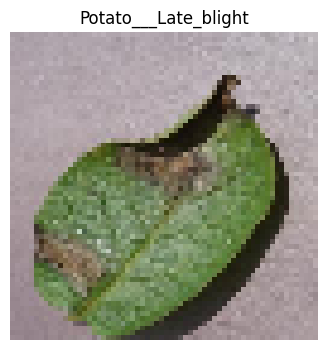

In [31]:
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(X_train[0], cv2.COLOR_BGR2RGB))
plt.title(y_train[0])
plt.axis("off")
plt.show()

In [32]:
X_train = np.array(X_train)
X_val = np.array(X_val)

y_train = np.array(y_train)
y_val = np.array(y_val)
print("converted successully")


converted successully


In [33]:
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(1721, 64, 64, 3)
(431, 64, 64, 3)
(1721,)
(431,)


In [34]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
print("Images Flattered successfully")

Images Flattered successfully


In [35]:
print("Training shape:",X_train.shape)
print("Validation shape:",X_val.shape)

Training shape: (1721, 12288)
Validation shape: (431, 12288)


In [36]:
X_train=X_train/255.0
X_val=X_val/255.0
print("Normalization cmpleted!")

Normalization cmpleted!


In [37]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.fit_transform(y_val)
print(" Labels Encoded successfully")

 Labels Encoded successfully


In [38]:
print("Encoded Classes")
print(encoder.classes_)

print()
print("firsy 10 labels")
print(y_train[:10])

Encoded Classes
['Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']

firsy 10 labels
[1 1 1 1 1 1 1 1 1 1]


In [39]:
print("Training Features shape:",X_train.shape)
print("Training Labels shape:",y_train.shape)
print()
print("Validation Features shape:",X_val.shape)
print("Validation Labels shape:",y_val.shape)

Training Features shape: (1721, 12288)
Training Labels shape: (1721,)

Validation Features shape: (431, 12288)
Validation Labels shape: (431,)


In [40]:
logistic_model = LogisticRegression(max_iter=1000)
print("logistic regression method created successfully")

logistic regression method created successfully


In [41]:
logistic_model.fit(X_train, y_train)
print("model completed successfully")

model completed successfully


In [42]:
y_pred = logistic_model.predict(X_val)
print("prediction completed successfully")

prediction completed successfully


In [43]:
print("Actual Labels:",y_val[:10])
print("Predicted Labels:",y_pred[:10])

Actual Labels: [1 1 1 1 1 1 1 1 1 1]
Predicted Labels: [1 1 1 1 1 1 1 1 1 1]


In [44]:
acc = accuracy_score(y_val, y_pred)
print("Accuracy:",round(acc*100,2),"%")

Accuracy: 90.95 %


In [45]:
cmx = confusion_matrix(y_val, y_pred)
print(cmx)

[[186  14   0]
 [  8 189   3]
 [  0  14  17]]


In [46]:
print(classification_report(y_val, y_pred,target_names=encoder.classes_))

                       precision    recall  f1-score   support

Potato___Early_blight       0.96      0.93      0.94       200
 Potato___Late_blight       0.87      0.94      0.91       200
     Potato___healthy       0.85      0.55      0.67        31

             accuracy                           0.91       431
            macro avg       0.89      0.81      0.84       431
         weighted avg       0.91      0.91      0.91       431



In [47]:
predicted_labels = encoder.inverse_transform(y_pred[:10])
print("first 10 predicted disease names:")
print(predicted_labels)

first 10 predicted disease names:
['Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight']


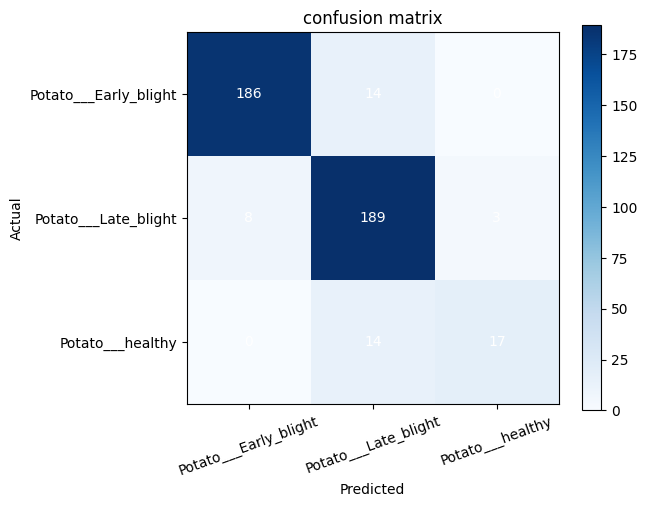

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cmx,cmap="Blues")
plt.title("confusion matrix")
plt.colorbar()
plt.xticks(range(3),encoder.classes_, rotation=20)
plt.yticks(range(3),encoder.classes_)
for i in range(3):
  for j in range(3):
    plt.text(j,i,cmx[i,j],ha="center",va="center",color="white")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
print("="*40)
print("Logistic regression completed successfully")
print("="*40)
print(f"Accuracy:{acc*100:.2f}%")

Logistic regression completed successfully
Accuracy:90.95%


In [52]:
svm_model = SVC(kernel="linear")
print("Support vector machine method created successfully")

Support vector machine method created successfully


In [53]:
svm_model.fit(X_train, y_train)
print("Model trained successfully")


Model trained successfully


In [62]:
y_pred = svm_model.predict(X_val)
print("Prediction completed")


Prediction completed


In [70]:
cmx = confusion_matrix(y_val, y_pred)
print("Confusion matrix:")
print(cmx)

Confusion matrix:
[[183  17   0]
 [  9 188   3]
 [  1   8  22]]


In [63]:
acc = accuracy_score(y_val, y_pred)
print("Accuracy:", round(acc * 100, 2), "%")

Accuracy: 91.18 %


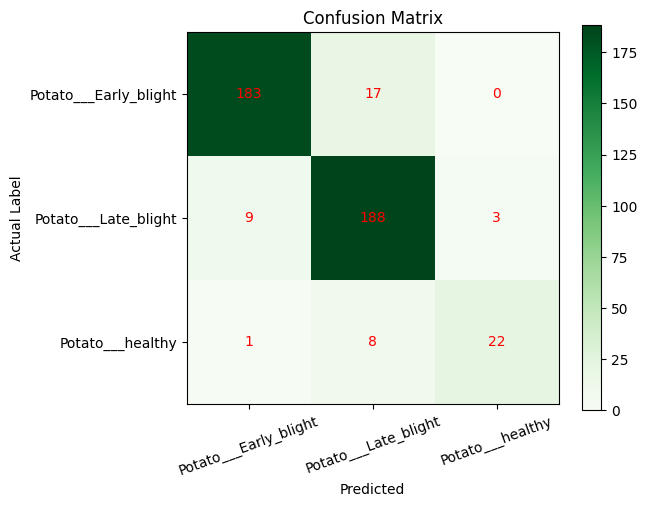

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(cmx, cmap=plt.cm.Greens)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(3), encoder.classes_, rotation=20)
plt.yticks(range(3), encoder.classes_)

for i in range(3):
    for j in range(3):
        plt.text(j, i, cmx[i, j],
                 ha='center',
                 va='center',
                 color="red")

plt.xlabel('Predicted')
plt.ylabel('Actual Label')

plt.show()

In [78]:
svm_acc = accuracy_score(y_val, y_pred)
print("Accuracy:", round(svm_acc * 100, 2), "%")

Accuracy: 91.18 %


In [101]:
from google.colab import files

uploaded = files.upload()

Saving Leaf image.jpg to Leaf image (1).jpg


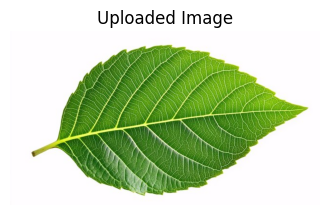

In [102]:
image_name = list(uploaded.keys())[0]
image = cv2.imread(image_name)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(4,4))
plt.imshow(image_rgb)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()


In [103]:
test_image = cv2.resize(image, image_size)
test_image = np.array(test_image)
test_image = test_image.reshape(1, -1)
test_image = test_image / 255.0
print("image preprocessed successufully")

image preprocessed successufully


In [104]:
prediction = svm_model.predict(test_image)
predicted_disease = encoder.inverse_transform(prediction)
print("Predicted Disease:", predicted_disease[0])

Predicted Disease: Potato___healthy


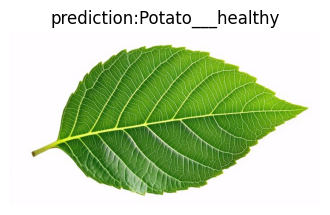

In [105]:
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("prediction:" +predicted_disease[0])
plt.axis("off")
plt.show()

In [110]:
if predicted_disease[0] == "Potato___Early_blight":
    print("Disease: Early Blight")
    print("Advice: Remove infected leaves and apply fungicide.")
elif predicted_disease[0] == "Potato___Late_blight":
    print("Disease: Late Blight")
    print("Advice: Remove infected leaves and apply fungicide.")
else:
  print("Disease: Healthy")
  print("Advice: No disease detected.continue regular crop care.")

Disease: Healthy
Advice: No disease detected.continue regular crop care.


In [113]:
comparison = {
    "Model":["Logistic Regression","Support vector machine"],
    "Accuracy":[acc *100,svm_acc *100]
}
import pandas as pd
comparison_df = pd.DataFrame(comparison)
comparison_df


,Model,Accuracy
0,Logistic Regression,91.183295
1,Support vector machine,91.183295


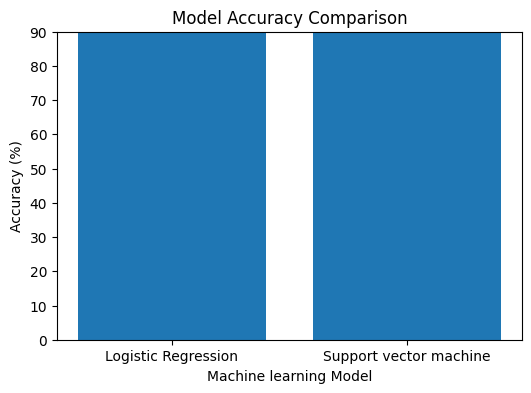

In [117]:
plt.figure(figsize=(6,4))
plt.bar(comparison_df["Model"],comparison_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 90)
plt.show()

In [118]:
if svm_acc> acc:
  print("Best Model:Support vector machine")
else:
  print("Best Model:Logistic regression")

Best Model:Logistic regression
